In [1]:
from scipy.stats import entropy
from math import log2
import numpy as np

In [2]:
def calculate_entropy(probs, tell_if_normalized = True):
    """
    Calculate the Shannon entropy of a list of probabilities.

    :param probs: List or dictionary of probabilities.
    :param tell_if_normalized: If True, print a message if the probabilities are normalized.
    :return: Shannon entropy
    """
    if type(probs) == dict:
        probs_values = list(probs.values())
    elif type(probs) == list:
        probs_values = probs
    if sum(probs_values) != 1:
        if tell_if_normalized:
            print(f'Normalized {probs_values} to sum to 1')
        probs_values = [float(i)/sum(probs_values) for i in probs_values]
        
    my_entropy = entropy(list(probs_values), base = 2)
    return my_entropy

In [3]:
n= 10
a = lambda n:  [1/n for _ in range(n)]
a

<function __main__.<lambda>(n)>

In [4]:
calculate_entropy(a(25))*0.05

np.float64(0.23219280948873622)

In [5]:
for n in range(3,100):
    b = a(n)
    b[-2] += b[-1]
    b.pop(-1)
    print(calculate_entropy(b))

0.9182958340544894
1.5
1.9219280948873625
2.2516291673878226
2.521640636343319
2.75
2.9477027792200907
3.121928094887362
3.277613436819116
3.41829583405449
3.5465935642949384
3.664497779200462
3.7735572622751863
3.8749999999999996
3.96981578242681
4.058813890331201
4.142664355548848
4.221928094887361
4.297079327540664
4.3685225277282065
4.436605434317883
4.501629167387824
4.563856189774724
4.623516641218016
4.680813428089396
4.735926350629033
4.789015477886192
4.840223928941851
4.889680181354618
4.937499999999999
4.983788058752394
5.0286393118385755
5.072140159802109
5.114369445886758
5.1553993115748975
5.195295934496218
5.234120167580195
5.271928094887364
5.308771516813207
5.344698375159712
5.379753126795121
5.413977073182752
5.4474086518852305
5.480083695187448
5.512035660188275
5.54329583405449
Normalized [0.02040816326530612, 0.02040816326530612, 0.02040816326530612, 0.02040816326530612, 0.02040816326530612, 0.02040816326530612, 0.02040816326530612, 0.02040816326530612, 0.020408163

## Delta Size Loss for Different Size Loss Functions

In [6]:
delta_log_sizeloss = lambda k : 1 + log2(k)
delta_shannon_sizeloss = lambda k : 2/k
delta_dec_exp_sizeloss = lambda k : np.exp(-2/k) - 2*np.exp(-1/k) +1
delta_reciprocal_sizeloss = lambda k : - (3/2) * k

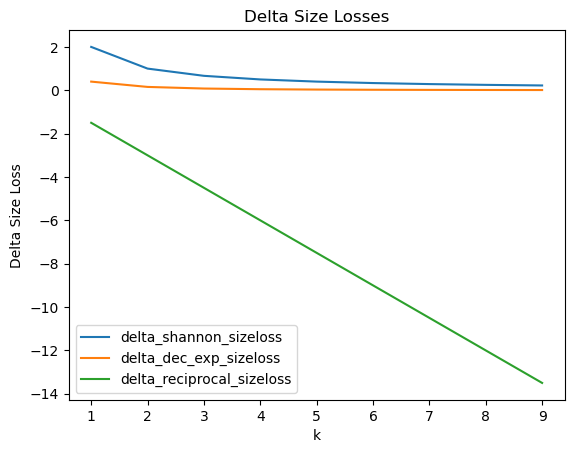

In [13]:
import matplotlib.pyplot as plt

k_values = np.arange(1, 10)
#plt.plot(k_values, [delta_log_sizeloss(k) for k in k_values], label='delta_log_sizeloss')
plt.plot(k_values, [delta_shannon_sizeloss(k) for k in k_values], label='delta_shannon_sizeloss')
plt.plot(k_values, [delta_dec_exp_sizeloss(k) for k in k_values], label='delta_dec_exp_sizeloss')
plt.plot(k_values, [delta_reciprocal_sizeloss(k) for k in k_values], label='delta_reciprocal_sizeloss')
plt.xlabel('k')
plt.ylabel('Delta Size Loss')
plt.title('Delta Size Losses')
plt.legend()
plt.show()